# Banking77 EDA

Self-contained ноутбук для расширенного анализа датасета `PolyAI/banking77`.
Здесь мы загружаем данные, сохраняем локальный snapshot, формируем `train/val/test`
и проводим подробный разведочный анализ текстовых обращений.

## Что анализируем

- размеры и структуру official split'ов;
- качество данных: пропуски, пустые тексты, дубликаты, конфликтующие дубликаты;
- распределение классов и степень дисбаланса;
- распределение длин сообщений в символах и словах;
- различия по длинам между классами;
- частотные униграммы и биграммы.

In [13]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datasets import load_dataset, load_from_disk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.figsize"] = (10, 6)

PROJECT_ROOT = Path(r"/home/sukuna/Projects/RNN")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
SNAPSHOT_DIR = RAW_DATA_DIR / "banking77_snapshot"
LABEL_MAPPING_PATH = RAW_DATA_DIR / "label_mapping.json"

DATASET_NAME = "PolyAI/banking77"
DATASET_REVISION = "refs/pr/6"
RANDOM_STATE = 42
VAL_SIZE = 0.2
WHITESPACE_RE = re.compile(r"\s+")

In [14]:
def normalize_text(text: str) -> str:
    text = "" if text is None else str(text)
    text = text.strip().lower()
    return WHITESPACE_RE.sub(" ", text)


def load_banking77_snapshot(force_refresh: bool = False):
    RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
    if SNAPSHOT_DIR.exists() and not force_refresh:
        return load_from_disk(str(SNAPSHOT_DIR))

    dataset = load_dataset(DATASET_NAME, revision=DATASET_REVISION, cache_dir=str(RAW_DATA_DIR / "hf_cache"))
    dataset.save_to_disk(str(SNAPSHOT_DIR))
    label_mapping = {i: label for i, label in enumerate(dataset["train"].features["label"].names)}
    LABEL_MAPPING_PATH.write_text(json.dumps(label_mapping, indent=2, ensure_ascii=False), encoding="utf-8")
    return dataset


def split_to_frame(dataset, split_name: str) -> pd.DataFrame:
    label_names = list(dataset["train"].features["label"].names)
    frame = dataset[split_name].to_pandas()[["text", "label"]].copy()
    frame["label_name"] = frame["label"].map(lambda idx: label_names[int(idx)])
    frame["text_normalized"] = frame["text"].map(normalize_text)
    frame["char_length"] = frame["text_normalized"].str.len()
    frame["word_length"] = frame["text_normalized"].str.split().str.len()
    return frame


def build_experiment_splits(dataset):
    official_train = split_to_frame(dataset, "train")
    official_test = split_to_frame(dataset, "test")

    train_df, val_df = train_test_split(
        official_train,
        test_size=VAL_SIZE,
        random_state=RANDOM_STATE,
        stratify=official_train["label"],
    )

    return {
        "official_train": official_train.reset_index(drop=True),
        "official_test": official_test.reset_index(drop=True),
        "train": train_df.reset_index(drop=True),
        "val": val_df.reset_index(drop=True),
        "test": official_test.reset_index(drop=True),
    }


def summarize_splits(split_frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for split_name, frame in split_frames.items():
        rows.append(
            {
                "split": split_name,
                "rows": int(len(frame)),
                "unique_labels": int(frame["label"].nunique()),
                "missing_texts": int(frame["text"].isna().sum()),
                "missing_labels": int(frame["label"].isna().sum()),
                "mean_char_length": round(float(frame["char_length"].mean()), 2),
                "mean_word_length": round(float(frame["word_length"].mean()), 2),
            }
        )
    return pd.DataFrame(rows).sort_values("split").reset_index(drop=True)


def duplicate_rows(frame: pd.DataFrame) -> pd.DataFrame:
    duplicated_mask = frame["text_normalized"].duplicated(keep=False)
    duplicated = frame.loc[duplicated_mask, ["text", "text_normalized", "label_name"]].copy()
    return duplicated.sort_values(["text_normalized", "label_name"]).reset_index(drop=True)


def conflicting_duplicates(frame: pd.DataFrame) -> pd.DataFrame:
    grouped = (
        frame.groupby("text_normalized")
        .agg(
            labels_count=("label_name", "nunique"),
            labels=("label_name", lambda values: ", ".join(sorted(set(values)))),
            examples_count=("text", "count"),
        )
        .reset_index()
    )
    return grouped[grouped["labels_count"] > 1].sort_values(["labels_count", "examples_count"], ascending=False)


def anomaly_summary(frame: pd.DataFrame) -> pd.DataFrame:
    long_threshold = int(frame["char_length"].quantile(0.99))
    return pd.DataFrame(
        [
            {"kind": "Пустой текст после нормализации", "count": int(frame["text_normalized"].eq("").sum())},
            {"kind": "Очень короткие сообщения (<= 2 слов)", "count": int((frame["word_length"] <= 2).sum())},
            {"kind": f"Очень длинные сообщения (>= {long_threshold} символов)", "count": int((frame["char_length"] >= long_threshold).sum())},
        ]
    )


def top_ngrams(texts: pd.Series, ngram_range=(1, 1), top_n: int = 20, min_df: int = 2) -> pd.DataFrame:
    vectorizer = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
    matrix = vectorizer.fit_transform(texts.tolist())
    counts = matrix.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()
    return (
        pd.DataFrame({"term": vocab, "count": counts})
        .sort_values("count", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

In [15]:
dataset = load_banking77_snapshot()
official_counts = {split_name: len(split) for split_name, split in dataset.items()}
label_count = len(dataset["train"].features["label"].names)

assert official_counts == {"train": 10003, "test": 3080}
assert label_count == 77

print("Размеры official split'ов:", official_counts)
print("Количество классов:", label_count)

Размеры official split'ов: {'train': 10003, 'test': 3080}
Количество классов: 77


In [16]:
split_frames = build_experiment_splits(dataset)
split_summary = summarize_splits(split_frames)
split_summary

,split,rows,unique_labels,missing_texts,missing_labels,mean_char_length,mean_word_length
0,official_test,3080,77,0,0,54.19,10.95
1,official_train,10003,77,0,0,59.41,11.95
2,test,3080,77,0,0,54.19,10.95
3,train,8002,77,0,0,59.53,11.97
4,val,2001,77,0,0,58.95,11.88


## Базовые статистики по длине сообщений

In [17]:
official_train = split_frames["official_train"]

length_stats = official_train[["char_length", "word_length"]].describe().T.round(2)
length_stats

,count,mean,std,min,25%,50%,75%,max
char_length,10003.0,59.41,40.77,13.0,36.0,47.0,64.0,429.0
word_length,10003.0,11.95,7.89,2.0,7.0,10.0,13.0,79.0


In [18]:
quality_summary = pd.DataFrame(
    {
        "Показатель": [
            "Количество строк",
            "Количество классов",
            "Пропуски в тексте",
            "Пропуски в метке",
            "Пустые тексты после нормализации",
            "Уникальные нормализованные тексты",
        ],
        "Значение": [
            len(official_train),
            official_train["label"].nunique(),
            int(official_train["text"].isna().sum()),
            int(official_train["label"].isna().sum()),
            int(official_train["text_normalized"].eq("").sum()),
            official_train["text_normalized"].nunique(),
        ],
    }
)
quality_summary

,Показатель,Значение
0,Количество строк,10003
1,Количество классов,77
2,Пропуски в тексте,0
3,Пропуски в метке,0
4,Пустые тексты после нормализации,0
5,Уникальные нормализованные тексты,9999


## Дубликаты и аномалии

In [19]:
duplicates = duplicate_rows(official_train)
pd.DataFrame(
    {
        "Показатель": ["Строк-дубликатов", "Уникальных дублирующихся текстов"],
        "Значение": [len(duplicates), duplicates["text_normalized"].nunique() if not duplicates.empty else 0],
    }
)

,Показатель,Значение
0,Строк-дубликатов,8
1,Уникальных дублирующихся текстов,4


In [20]:
duplicates.head(15)

,text,text_normalized,label_name
0,Do I need to go to a physical bank to change m...,do i need to go to a physical bank to change m...,change_pin
1,\nDo I need to go to a physical bank to change...,do i need to go to a physical bank to change m...,change_pin
2,I can't seem to be able to use my card,i can't seem to be able to use my card,card_not_working
3,\nI can't seem to be able to use my card\n\n\n,i can't seem to be able to use my card,card_not_working
4,\nI put the wrong pin too many times and now i...,i put the wrong pin too many times and now it ...,pin_blocked
5,I put the wrong pin too many times and now it ...,i put the wrong pin too many times and now it ...,pin_blocked
6,Where can I withdraw money from?,where can i withdraw money from?,atm_support
7,\nWhere can I withdraw money from?,where can i withdraw money from?,atm_support


In [21]:
conflicts = conflicting_duplicates(official_train)
print(f"Конфликтующих дубликатов: {len(conflicts)}")
conflicts.head(10)

Конфликтующих дубликатов: 0


,text_normalized,labels_count,labels,examples_count


In [22]:
anomaly_summary(official_train)

,kind,count
0,Пустой текст после нормализации,0
1,Очень короткие сообщения (<= 2 слов),6
2,Очень длинные сообщения (>= 220 символов),104


## Баланс классов

In [23]:
label_counts = official_train["label_name"].value_counts().rename_axis("label_name").reset_index(name="count")
balance_summary = pd.DataFrame(
    {
        "Показатель": [
            "Среднее число примеров на класс",
            "Медиана числа примеров на класс",
            "Минимум",
            "Максимум",
            "Отношение max/min",
        ],
        "Значение": [
            round(label_counts["count"].mean(), 2),
            round(label_counts["count"].median(), 2),
            int(label_counts["count"].min()),
            int(label_counts["count"].max()),
            round(label_counts["count"].max() / label_counts["count"].min(), 2),
        ],
    }
)
balance_summary

,Показатель,Значение
0,Среднее число примеров на класс,129.91
1,Медиана числа примеров на класс,127.00
2,Минимум,35.00
3,Максимум,187.00
4,Отношение max/min,5.34


/tmp/ipykernel_5431/3200599739.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_classes, y="label_name", x="count", ax=axes[0], palette="viridis")
/tmp/ipykernel_5431/3200599739.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rare_classes, y="label_name", x="count", ax=axes[1], palette="crest")


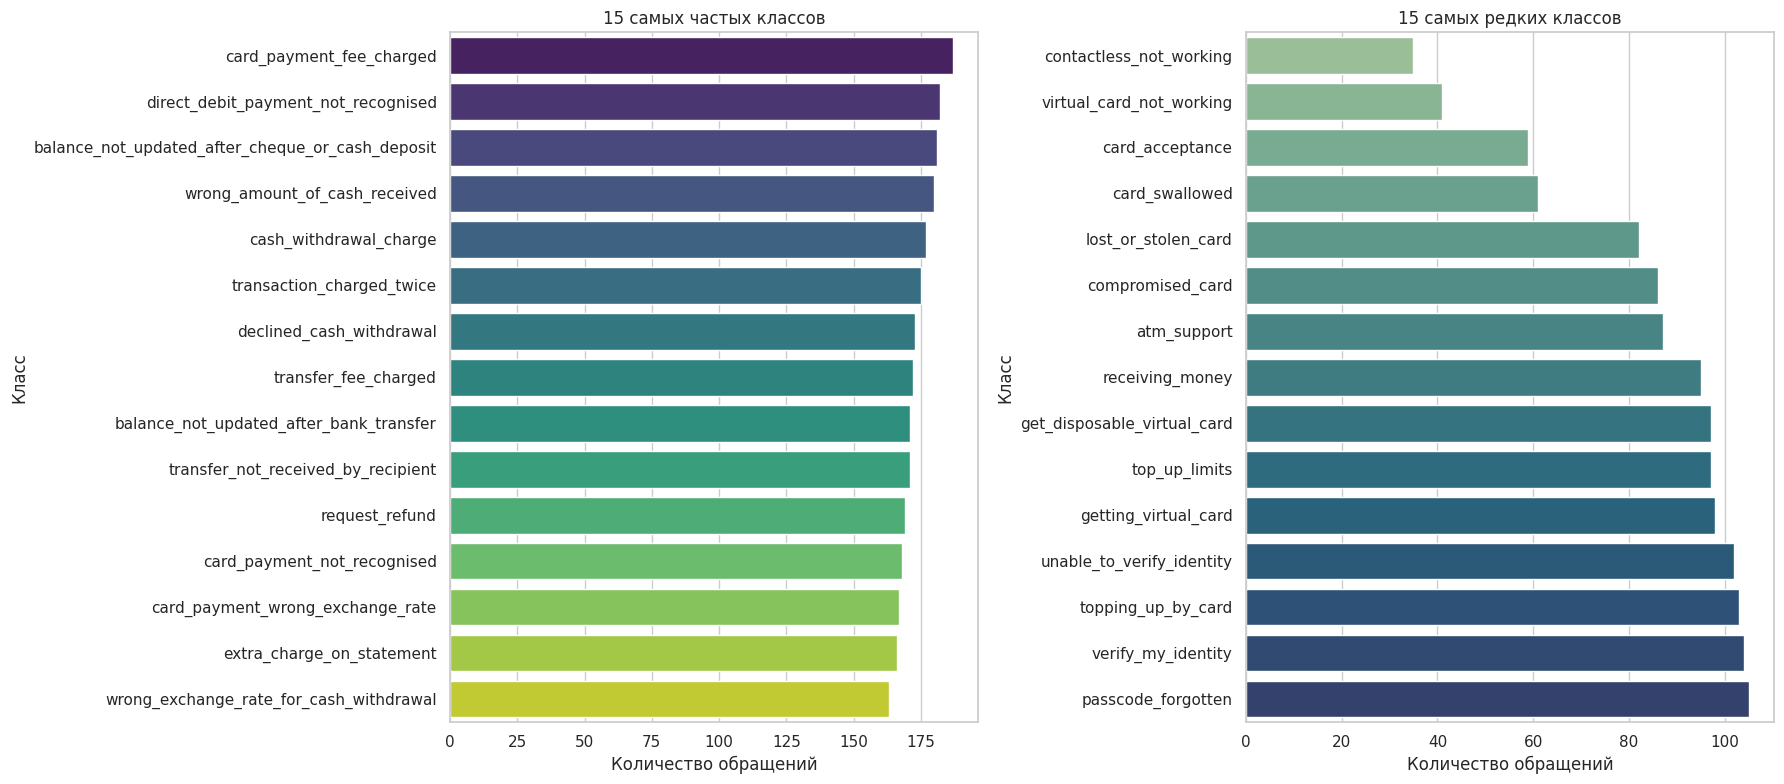

In [24]:
top_classes = label_counts.head(15)
rare_classes = label_counts.tail(15).sort_values("count", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.barplot(data=top_classes, y="label_name", x="count", ax=axes[0], palette="viridis")
axes[0].set_title("15 самых частых классов")
axes[0].set_xlabel("Количество обращений")
axes[0].set_ylabel("Класс")

sns.barplot(data=rare_classes, y="label_name", x="count", ax=axes[1], palette="crest")
axes[1].set_title("15 самых редких классов")
axes[1].set_xlabel("Количество обращений")
axes[1].set_ylabel("Класс")

plt.tight_layout()
plt.show()

/tmp/ipykernel_5431/2921771138.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=label_counts, y="label_name", x="count", palette="viridis")


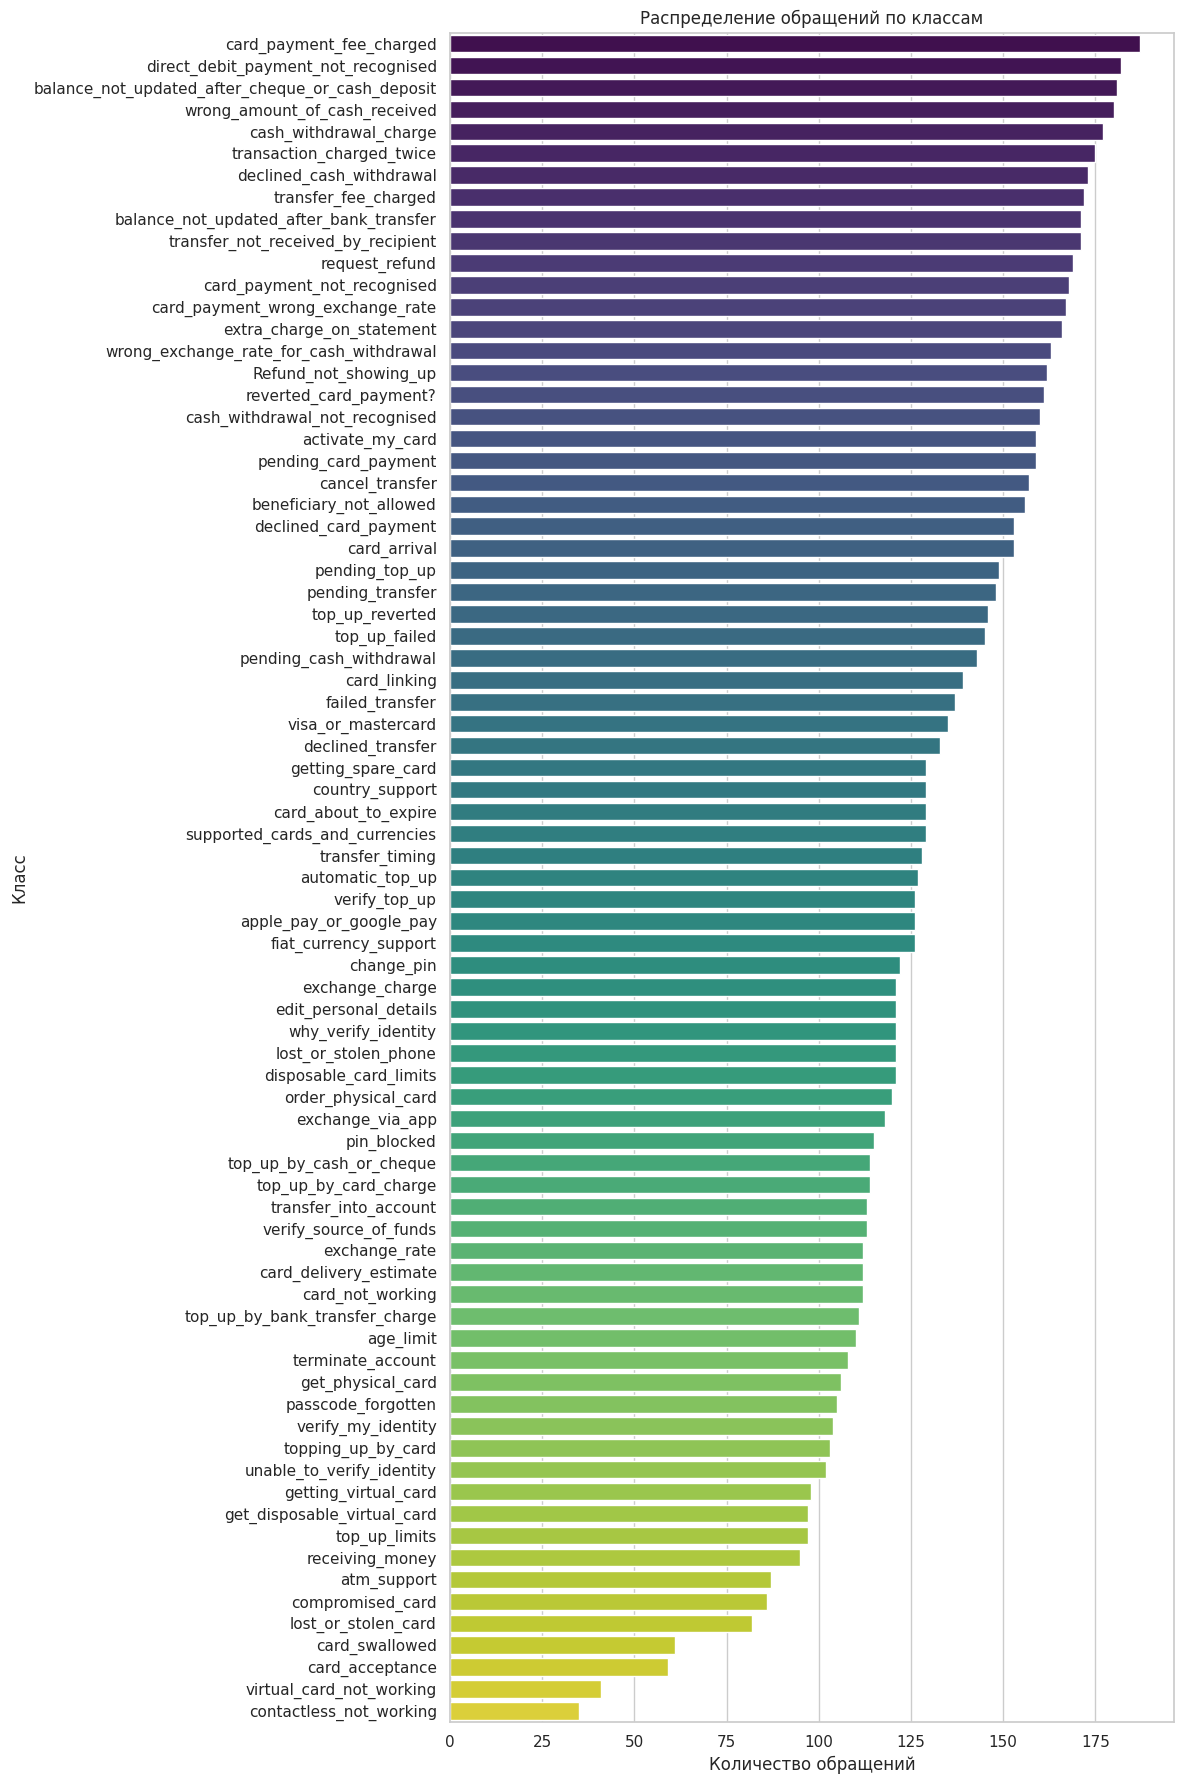

In [25]:
plt.figure(figsize=(12, 18))
sns.barplot(data=label_counts, y="label_name", x="count", palette="viridis")
plt.title("Распределение обращений по классам")
plt.xlabel("Количество обращений")
plt.ylabel("Класс")
plt.tight_layout()
plt.show()

## Анализ длины сообщений

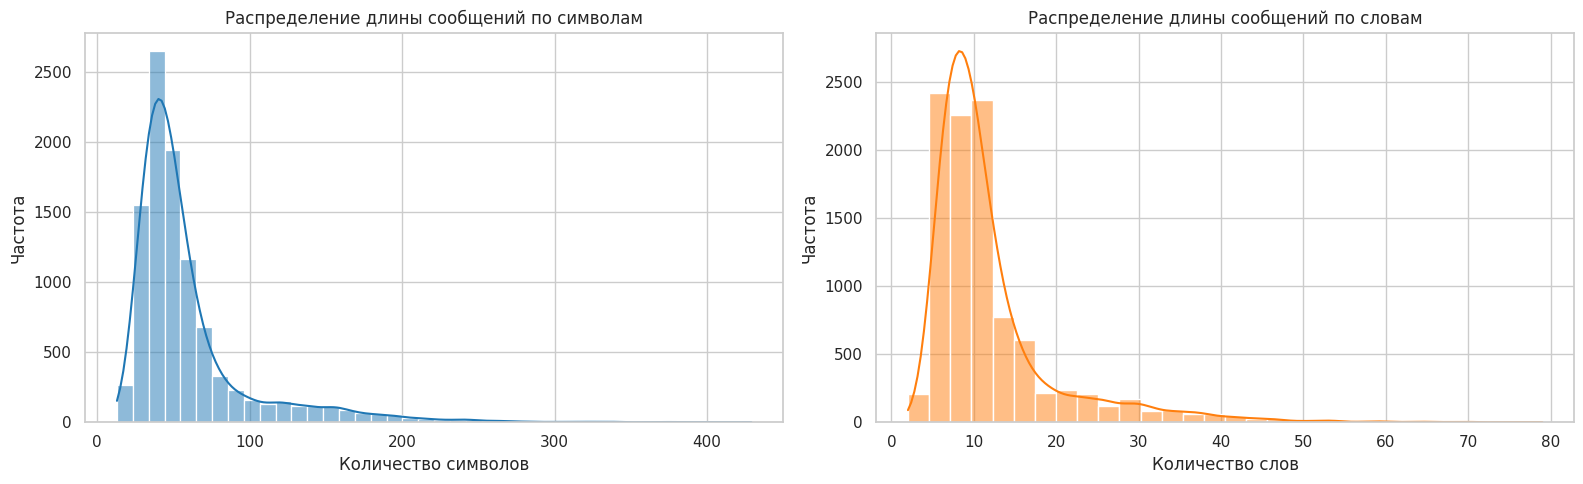

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(official_train["char_length"], bins=40, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Распределение длины сообщений по символам")
axes[0].set_xlabel("Количество символов")
axes[0].set_ylabel("Частота")

sns.histplot(official_train["word_length"], bins=30, kde=True, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Распределение длины сообщений по словам")
axes[1].set_xlabel("Количество слов")
axes[1].set_ylabel("Частота")

plt.tight_layout()
plt.show()

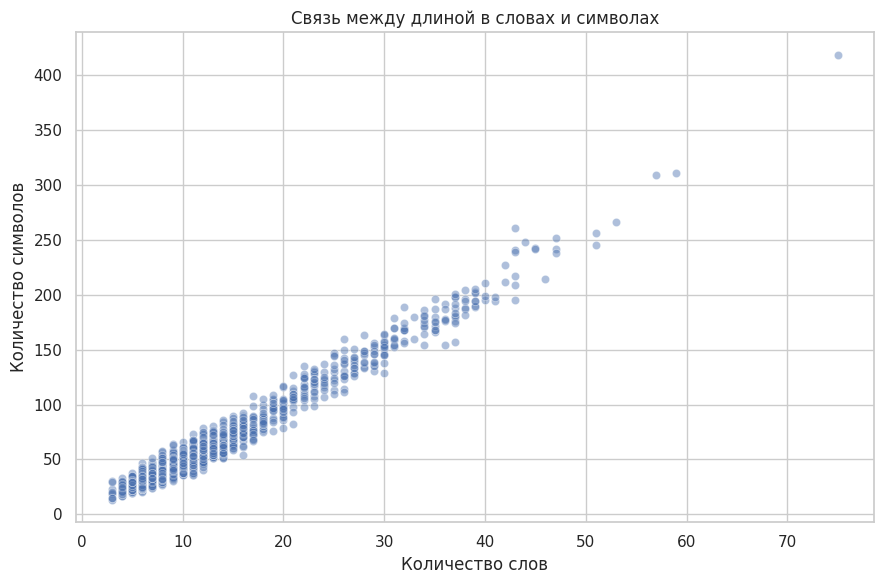

In [27]:
sampled = official_train.sample(n=min(2000, len(official_train)), random_state=RANDOM_STATE)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=sampled, x="word_length", y="char_length", alpha=0.45, s=35)
plt.title("Связь между длиной в словах и символах")
plt.xlabel("Количество слов")
plt.ylabel("Количество символов")
plt.tight_layout()
plt.show()

/tmp/ipykernel_5431/1912808754.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=split_length_df, x="split", y="char_length", ax=axes[0], palette="Set2")
/tmp/ipykernel_5431/1912808754.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=split_length_df, x="split", y="word_length", ax=axes[1], palette="Set2")


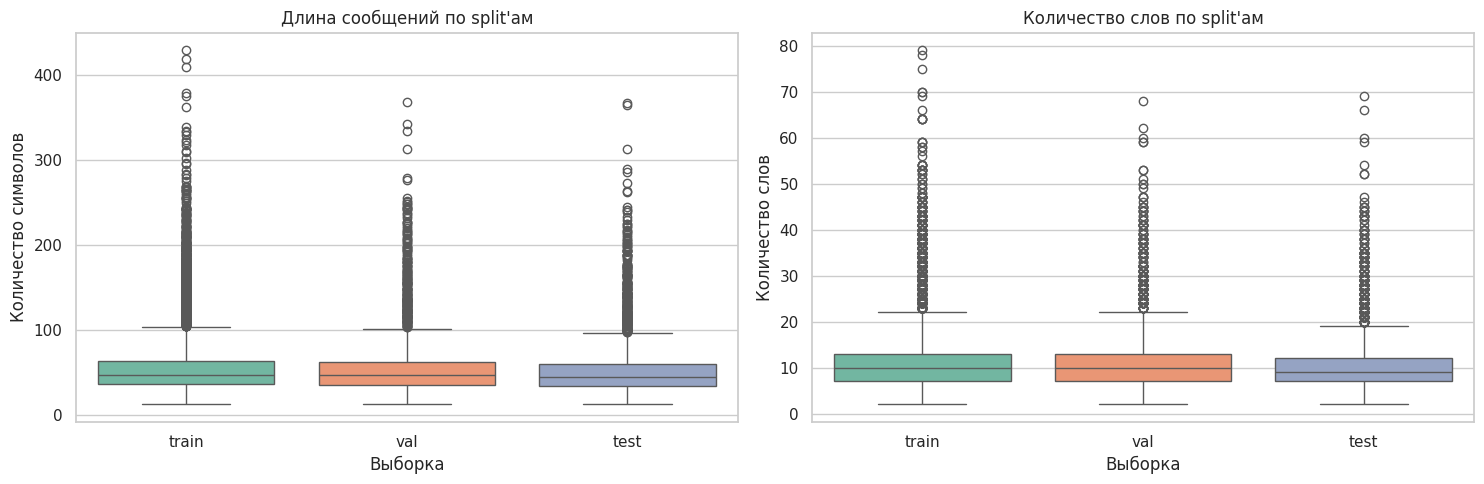

In [28]:
split_length_df = pd.concat(
    [
        split_frames["train"].assign(split="train"),
        split_frames["val"].assign(split="val"),
        split_frames["test"].assign(split="test"),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=split_length_df, x="split", y="char_length", ax=axes[0], palette="Set2")
axes[0].set_title("Длина сообщений по split'ам")
axes[0].set_xlabel("Выборка")
axes[0].set_ylabel("Количество символов")

sns.boxplot(data=split_length_df, x="split", y="word_length", ax=axes[1], palette="Set2")
axes[1].set_title("Количество слов по split'ам")
axes[1].set_xlabel("Выборка")
axes[1].set_ylabel("Количество слов")

plt.tight_layout()
plt.show()

In [29]:
class_length_stats = (
    official_train.groupby("label_name")
    .agg(
        count=("text", "count"),
        mean_char_length=("char_length", "mean"),
        mean_word_length=("word_length", "mean"),
    )
    .reset_index()
    .sort_values("mean_char_length", ascending=False)
)

class_length_stats.head(10)

,label_name,count,mean_char_length,mean_word_length
66,transfer_not_received_by_recipient,171,91.391813,17.549708
64,transfer_fee_charged,172,89.494186,17.395349
47,pending_cash_withdrawal,143,85.720280,16.531469
63,transaction_charged_twice,175,84.045714,15.988571
36,failed_transfer,137,83.562044,15.992701
49,pending_transfer,148,80.898649,15.243243
76,wrong_exchange_rate_for_cash_withdrawal,163,80.730061,15.460123
29,direct_debit_payment_not_recognised,182,78.620879,15.989011
0,Refund_not_showing_up,162,77.796296,15.808642
21,cash_withdrawal_not_recognised,160,76.793750,15.437500


/tmp/ipykernel_5431/4194685647.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=longest_classes, y="label_name", x="mean_char_length", palette="flare")


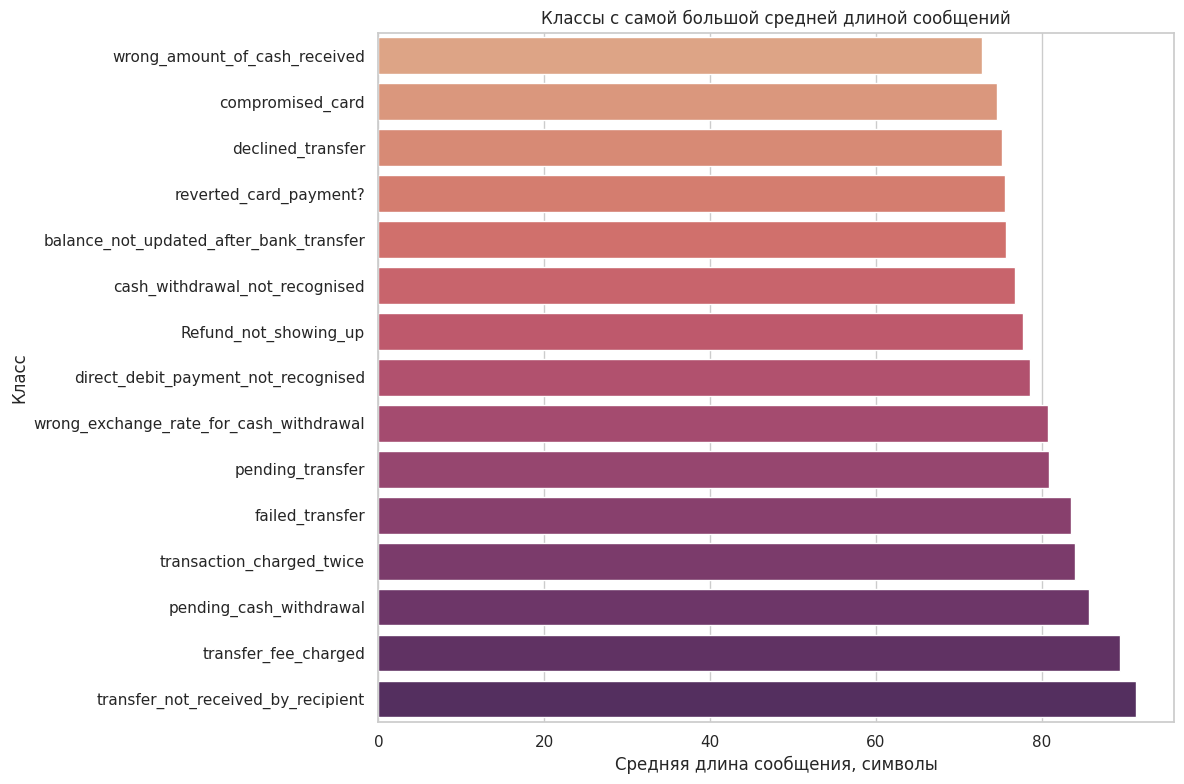

In [30]:
longest_classes = class_length_stats.head(15).sort_values("mean_char_length", ascending=True)

plt.figure(figsize=(12, 8))
sns.barplot(data=longest_classes, y="label_name", x="mean_char_length", palette="flare")
plt.title("Классы с самой большой средней длиной сообщений")
plt.xlabel("Средняя длина сообщения, символы")
plt.ylabel("Класс")
plt.tight_layout()
plt.show()

## Частотные n-граммы

In [31]:
unigram_df = top_ngrams(official_train["text_normalized"], ngram_range=(1, 1), top_n=20)
unigram_df

,term,count
0,my,5684
1,to,4039
2,the,3498
3,card,2682
4,is,2377
5,can,2070
6,it,2062
7,do,1849
8,for,1581
9,what,1542


/tmp/ipykernel_5431/896410962.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=unigram_df, y="term", x="count", palette="magma")


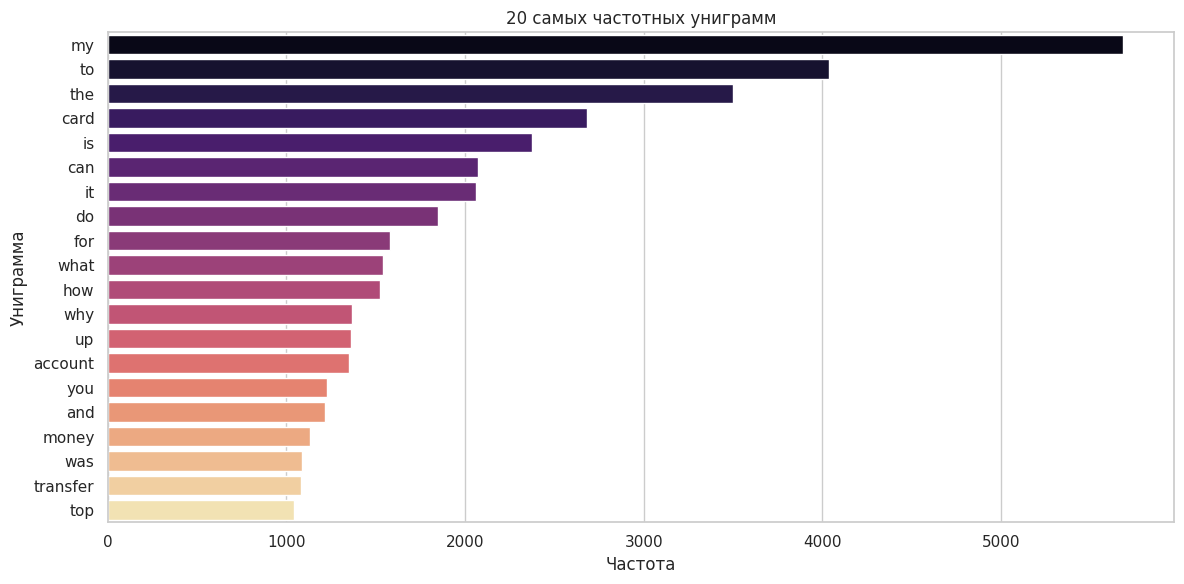

In [32]:
plt.figure(figsize=(12, 6))
sns.barplot(data=unigram_df, y="term", x="count", palette="magma")
plt.title("20 самых частотных униграмм")
plt.xlabel("Частота")
plt.ylabel("Униграмма")
plt.tight_layout()
plt.show()

In [33]:
bigram_df = top_ngrams(official_train["text_normalized"], ngram_range=(2, 2), top_n=20)
bigram_df

,term,count
0,my card,1353
1,my account,983
2,top up,955
3,how do,499
4,can you,493
5,on my,433
6,need to,428
7,what is,366
8,is there,350
9,is the,347


/tmp/ipykernel_5431/1285895700.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bigram_df, y="term", x="count", palette="rocket")


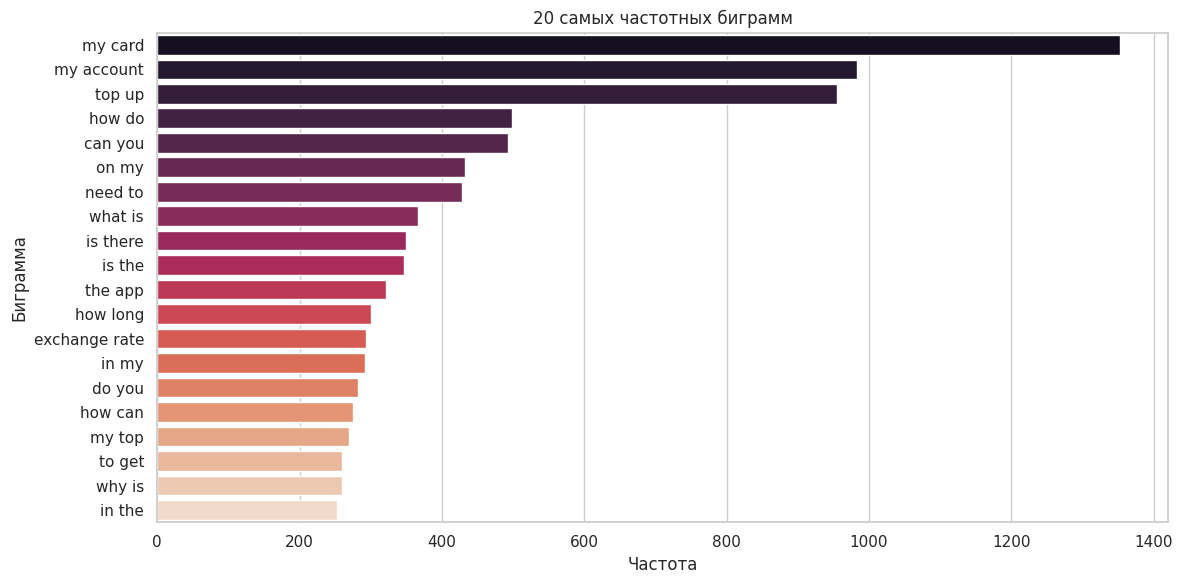

In [34]:
plt.figure(figsize=(12, 6))
sns.barplot(data=bigram_df, y="term", x="count", palette="rocket")
plt.title("20 самых частотных биграмм")
plt.xlabel("Частота")
plt.ylabel("Биграмма")
plt.tight_layout()
plt.show()

## Итоговый вывод

Проведённый EDA показал, что датасет `Banking77` в текущей постановке хорошо подходит для задачи многоклассовой классификации текстовых обращений. В official split содержится `10 003` объектов в train и `3 080` объектов в test, всего представлено `77` классов. Для экспериментов дополнительно сформировано разбиение `8 002 / 2 001 / 3 080` для `train / val / test`, при этом во всех выборках сохранено полное покрытие по классам.

С точки зрения качества данных набор оказался достаточно чистым: пропуски в тексте и метках отсутствуют, пустых текстов после нормализации также не обнаружено. Из `10 003` объектов train-части получено `9 999` уникальных нормализованных текстов, найдено только `8` строк-дубликатов, соответствующих `4` уникальным повторяющимся текстам, а конфликтующих дубликатов между разными классами не выявлено. Это означает, что на этапе baseline нет необходимости вводить сложную схему предварительной очистки данных, и можно сосредоточиться на качественном построении признаков и сравнении моделей.

Анализ длины сообщений показывает, что обращения в среднем короткие или средней длины: средняя длина составляет `59.41` символа и `11.95` слова, медиана равна `47` символам и `10` словам, максимальная длина достигает `429` символов и `79` слов. Такой профиль сообщений хорошо согласуется с применением TF-IDF и классических линейных моделей как сильного baseline. При этом самые длинные тексты в среднем наблюдаются в классах `transfer_not_received_by_recipient`, `transfer_fee_charged`, `pending_cash_withdrawal`, `transaction_charged_twice` и `failed_transfer`, что указывает на более подробное описание пользователями проблем, связанных с переводами и спорными транзакциями.

Распределение классов нельзя считать полностью равномерным, однако дисбаланс остаётся умеренным: среднее число объектов на класс равно `129.91`, медиана `127`, минимум `35`, максимум `187`, а отношение `max/min = 5.34`. Следовательно, при оценке моделей недостаточно ориентироваться только на accuracy; необходимо обязательно использовать `macro-F1`, чтобы корректно учитывать качество распознавания редких классов.

Частотный анализ лексики подтверждает прикладную специфику датасета: среди наиболее характерных униграмм выделяются `card`, `account`, `money`, `transfer`, а среди биграмм — `my card`, `my account`, `top up`, `exchange rate`. Это показывает, что в данных присутствуют устойчивые банковские формулировки и повторяющиеся языковые шаблоны, а значит unigram- и bigram-признаки действительно должны быть информативны для baseline-моделей.

## Практическое значение для следующего этапа

На основании проведённого анализа можно сделать вывод, что датасет готов к этапу построения baseline-моделей без дополнительной тяжёлой очистки. В качестве базового подхода оправдано использовать TF-IDF с униграммами и биграммами в сочетании с классическими алгоритмами, такими как Logistic Regression, Naive Bayes и Random Forest. При интерпретации результатов особое внимание следует уделять метрике `macro-F1`, а при анализе ошибок — семантически близким интентам из банковской предметной области, прежде всего связанным с переводами, картами, платежами и пополнениями, а также редким классам, где ожидается наибольшее число ошибок.